# Exploratory data analysis

,Dataset,Split,Proportion of label 1
0,Diabetes,Train,0.074420
1,Diabetes,Test,0.074742
2,Heart,Train,0.451754
3,Heart,Test,0.448276
4,Hepatitis,Train,0.209677
5,Hepatitis,Test,0.193548


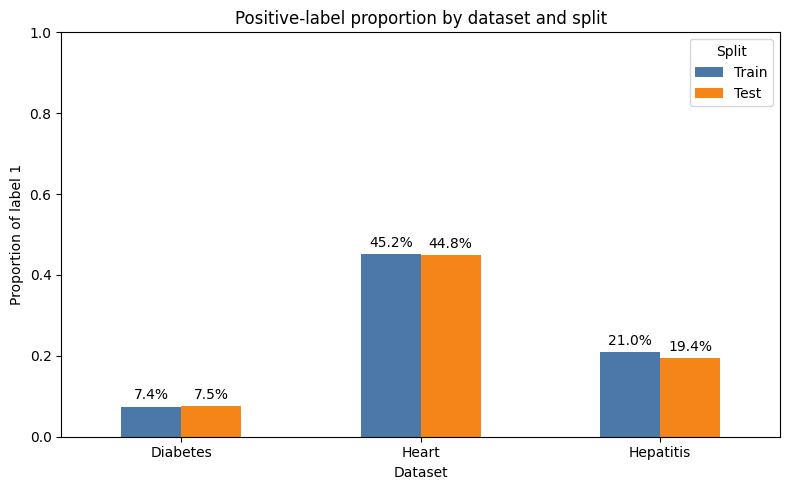

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Supports running the notebook either from its own folder or from the repository root.
data_dir = next(
    (path for path in (Path("../pre-processed"), Path("data/pre-processed")) if path.exists()),
    None,
)
if data_dir is None:
    raise FileNotFoundError("Could not find the data/pre-processed directory.")

target_columns = {
    "diabetes": "target",
    "heart": "target",
    "hepatitis": "target",
}

rows = []
for disease_name, target_column in target_columns.items():
    for split in ("train", "test"):
        data = pd.read_csv(data_dir / f"{disease_name}_{split}.csv")
        labels = data[target_column].dropna()
        rows.append({
            "Dataset": disease_name.title(),
            "Split": split.title(),
            "Proportion of label 1": labels.eq(1).mean(),
        })

label_proportions = pd.DataFrame(rows)
display(label_proportions)

plot_data = label_proportions.pivot(index="Dataset", columns="Split", values="Proportion of label 1")
ax = plot_data[["Train", "Test"]].plot(
    kind="bar",
    figsize=(8, 5),
    color=["#4C78A8", "#F58518"],
    rot=0,
)
ax.set_title("Positive-label proportion by dataset and split")
ax.set_ylabel("Proportion of label 1")
ax.set_xlabel("Dataset")
ax.set_ylim(0, 1)
ax.legend(title="Split")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", labels=[f"{bar.get_height():.1%}" for bar in container], padding=3)

plt.tight_layout()
plt.show()